In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from typing import Dict, List, Tuple

import torch
import torch.nn as nn

import torchvision
from torchvision import transforms

In [2]:
BATCH_SIZE = 128
LEARNING_RATE = 1e-5
NUM_EPOCHS = 20
SEED = 42

In [3]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
device = "cpu"
if torch.cuda.is_available():
    print(f"Cuda Version:{torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    device = "cuda"
print(f"Using device: {device}")

Cuda Version:12.8
GPU Memory: 15.6 GB
Using device: cuda


## Dataset Exploration

In [5]:
root_data_dir = Path('/kaggle/input/datasets/aditibindal/deeplense-dataset-for-ml4sci/dataset/')
no_1 = np.load(root_data_dir/'train/no/1.npy')
no_1.shape

(1, 150, 150)

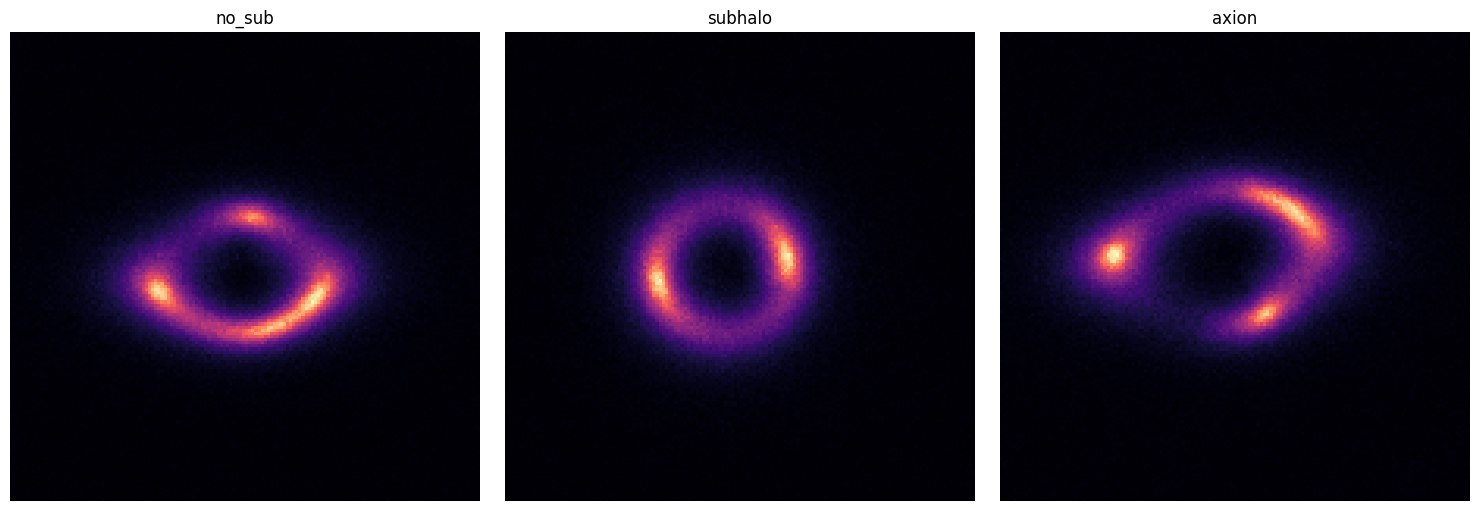

In [6]:
no = np.load(root_data_dir/'train/no/1000.npy')
subhalo = np.load(root_data_dir/'train/sphere/1000.npy')
axion = np.load(root_data_dir/'train/vort/1000.npy')

def plot_train_samples(samples_dict):
    plt.figure(figsize=(15, 5))
    
    for i, (label, img) in enumerate(samples_dict.items()):
        plt.subplot(1, 3, i + 1)
        plt.imshow(img[0], cmap="magma")
        plt.title(label)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

samples = {
    "no_sub": no,
    "subhalo": subhalo,
    "axion": axion,
}

plot_train_samples(samples)

In [7]:
def check_data_split(base_path: Path):
    stats = {}
    for split in ['train', 'val']:
        split_path = base_path / split
        stats[split] = {}
        for class_name in os.listdir(split_path):
            class_path = split_path / class_name
            if class_path.is_dir():
                stats[split][class_name] = len(os.listdir(class_path))
                
    print(f"{'Split':<10} | {'Class':<10} | {'Count':<10}")
    print("-" * 35)
    total_train = 0
    total_val = 0
    
    for split, classes in stats.items():
        for class_name, count in classes.items():
            print(f"{split:<10} | {class_name:<10} | {count:<10}")
            if split == 'train': total_train += count
            else: total_val += count
            
    if total_train + total_val > 0:
        val_ratio = total_val / (total_train + total_val)
        print("-" * 35)
        print(f"Total Images: {total_train + total_val}")
        print(f"Validation Ratio: {val_ratio:.2%} (Target: 10.00%)")
        
check_data_split(root_data_dir)

Split      | Class      | Count     
-----------------------------------
train      | no         | 10000     
train      | vort       | 10000     
train      | sphere     | 10000     
val        | no         | 2500      
val        | vort       | 2500      
val        | sphere     | 2500      
-----------------------------------
Total Images: 37500
Validation Ratio: 20.00% (Target: 10.00%)


## Dataset Preparation

In [8]:
from torch.utils.data import Dataset, DataLoader, random_split

class DeepLenseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['no', 'sphere', 'vort'] 
        self.filepaths = []
        self.labels = []
        
        for label_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(self.root_dir, class_name)
            if os.path.exists(class_dir):
                for file in os.listdir(class_dir):
                    if file.endswith('.npy'):
                        self.filepaths.append(os.path.join(class_dir, file))
                        self.labels.append(label_idx)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, i):
        img_path = self.filepaths[i]
        image = np.load(img_path) 
        
        if image.ndim == 2:
            image = np.expand_dims(image, axis=0)
            
        image = torch.tensor(image, dtype=torch.float32)
        
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)

        label = self.labels[i]

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
def create_transform_pipelines():
    IMAGENET_MEAN = [0.485, 0.456, 0.406] 
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    # standard transformations (resize, center-crop, flip, rotate, normalize)
    train_transforms = transforms.Compose([
        transforms.Resize(256, antialias=True), 
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    
    val_transforms = transforms.Compose([
        transforms.Resize(256, antialias=True),
        transforms.CenterCrop(224),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    return train_transforms, val_transforms
    
train_transform, val_transform = create_transform_pipelines()

In [10]:
def create_datasets_and_dataloaders(data_dir,
                                  train_transform,
                                  val_transform,
                                  batch_size = BATCH_SIZE,
                                  num_workers = 2):

    train_dataset = DeepLenseDataset(root_dir=data_dir/"train", transform=train_transform)
    val_dataset = DeepLenseDataset(root_dir=data_dir/"train", transform=val_transform)
    test_dataset = DeepLenseDataset(root_dir=data_dir/"val", transform=val_transform)

    class_names = train_dataset.classes
    
    num_images = len(train_dataset)
    train_size = int(0.9 * num_images)
    val_size = num_images - train_size
    train_idx, val_idx = random_split(
        range(num_images), 
        [train_size, val_size], 
        generator=torch.Generator().manual_seed(42)
    )
    
    train_subset = torch.utils.data.Subset(train_dataset, train_idx)
    val_subset = torch.utils.data.Subset(val_dataset, val_idx)
    
    
    train_dataloader = DataLoader(dataset=train_subset,
                                 batch_size=batch_size,
                                 shuffle=True,
                                 num_workers=num_workers,
                                 pin_memory=True if device == "cuda" else False)

    val_dataloader = DataLoader(dataset=val_subset,
                                batch_size=batch_size,
                                shuffle=False,
                                num_workers=num_workers,
                                pin_memory=True if device == "cuda" else False)
    
    test_dataloader = DataLoader(dataset=test_dataset,
                                batch_size=batch_size,
                                shuffle=False,
                                num_workers=num_workers,
                                pin_memory=True if device == "cuda" else False)

    return train_subset, val_subset, test_dataset, train_dataloader, val_dataloader, test_dataloader, class_names

train_subset, val_subset, test_dataset, train_dataloader, val_dataloader, test_dataloader, class_names = create_datasets_and_dataloaders(
    data_dir=root_data_dir,
    train_transform=train_transform,
    val_transform=val_transform,
    batch_size=BATCH_SIZE,
    num_workers=2
)

print("=== DATASET AND DATALOADER SUMMARY ===")
print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")
print(f"Batch size: {train_dataloader.batch_size}")
print(f"Training batches per epoch: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

=== DATASET AND DATALOADER SUMMARY ===
Training samples: 27000
Validation samples: 3000
Test samples: 7500
Number of classes: 3
Class names: ['no', 'sphere', 'vort']
Batch size: 128
Training batches per epoch: 211
Validation batches: 24
Test batches: 59


### Setting up Pretrained Model

In [11]:
weights = torchvision.models.ResNet34_Weights.DEFAULT
model = torchvision.models.resnet34(weights=weights).to(device)

model

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 178MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
from torchsummary import summary
summary(model=model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [13]:
output_shape = len(class_names)
num_feat = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=num_feat,
              out_features=output_shape,
              bias=True)
).to(device)

summary(model, input_size=(3, 224, 224), device=device)
model = torch.compile(model, mode="reduce-overhead")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [14]:
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

## Training model

In [15]:
def train_step(model, dataloader, criterion, optimizer, device):

    model.train()

    train_loss, train_acc = 0, 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
    
        optimizer.zero_grad()
        
        y_pred = model(X)
        loss = criterion(y_pred, y)
        train_loss += loss.item()
    
        loss.backward()
    
        optimizer.step()

        y_pred_class = torch.argmax(y_pred, dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

def validation_step(model, dataloader, criterion, device):

    model.eval()

    val_loss, val_acc = 0, 0

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
        
            val_pred = model(X)
        
            loss = criterion(val_pred, y)
            val_loss += loss.item()    
            
            val_pred_class = torch.argmax(val_pred, dim=1)
            val_acc += (val_pred_class == y).sum().item()/len(val_pred)
    
    val_loss /= len(dataloader)
    val_acc /= len(dataloader)

    return val_loss, val_acc

In [16]:
def train(model,
          train_dataloader, 
          val_dataloader, 
          optimizer, 
          criterion, 
          num_epochs, 
          device, 
          model_name
         ):

    results = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    model.to(device)

    best_val_loss = float('inf')

    for epoch in tqdm(range(num_epochs)):
        train_loss, train_acc = train_step(model=model, 
                                           dataloader=train_dataloader, 
                                           criterion=criterion, 
                                           optimizer=optimizer, 
                                           device=device)
        
        val_loss, val_acc = validation_step(model=model, 
                                            dataloader=val_dataloader, 
                                            criterion=criterion, 
                                            device=device)

        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"val_loss: {val_loss:.4f} | "
          f"val_acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            print(f"New best model. Saving weights to 'best_{model_name}_model.pth'...")
            torch.save(model.state_dict(), f'best_{model_name}_model.pth')

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

    return model, results

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [18]:
from timeit import default_timer as timer
start_time = timer()

trained_model, results = train(model=model,
                       train_dataloader=train_dataloader,
                       val_dataloader=val_dataloader,
                       optimizer=optimizer,
                       criterion=loss_fn,
                       num_epochs=NUM_EPOCHS,
                       device=device,
                       model_name="classification_resnet34")

end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

W0328 07:57:23.696000 24 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch: 1 | train_loss: 1.1271 | train_acc: 0.3746 | val_loss: 1.0560 | val_acc: 0.4440
New best model. Saving weights to 'best_classification_resnet34_model.pth'...
Epoch: 2 | train_loss: 1.0047 | train_acc: 0.4780 | val_loss: 0.9806 | val_acc: 0.5142
New best model. Saving weights to 'best_classification_resnet34_model.pth'...
Epoch: 3 | train_loss: 0.8477 | train_acc: 0.5924 | val_loss: 0.7910 | val_acc: 0.6416
New best model. Saving weights to 'best_classification_resnet34_model.pth'...
Epoch: 4 | train_loss: 0.7027 | train_acc: 0.6871 | val_loss: 0.6249 | val_acc: 0.7269
New best model. Saving weights to 'best_classification_resnet34_model.pth'...
Epoch: 5 | train_loss: 0.5914 | train_acc: 0.7479 | val_loss: 0.5371 | val_acc: 0.7733
New best model. Saving weights to 'best_classification_resnet34_model.pth'...
Epoch: 6 | train_loss: 0.5168 | train_acc: 0.7823 | val_loss: 0.4686 | val_acc: 0.8101
New best model. Saving weights to 'best_classification_resnet34_model.pth'...
Epoch: 7 |

## Evaluation

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def evaluate_model(model, test_dataloader, criterion, device):
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    all_probs = [] 
    
    test_pbar = tqdm(test_dataloader, desc='Evaluating on test set')
    with torch.no_grad():
        for inputs, labels in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            probs = torch.nn.functional.softmax(outputs, dim=1)  
            _, predicted = torch.max(outputs, 1)
            
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())  
            
            test_pbar.set_postfix({'loss': loss.item(), 'acc': test_correct/test_total})
    
    test_loss = test_loss / len(test_dataloader.dataset)
    test_acc = test_correct / test_total
    
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    
    cm = confusion_matrix(all_labels, all_preds)
    
    all_labels_np = np.array(all_labels)
    all_probs_np = np.array(all_probs)
    
    n_classes = all_probs_np.shape[1]
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    # Calculate ROC AUC for each class
    for i in range(n_classes):
        binary_labels = (all_labels_np == i).astype(int)
        class_probs = all_probs_np[:, i]
        
        fpr[i], tpr[i], _ = roc_curve(binary_labels, class_probs)
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    macro_roc_auc = sum(roc_auc.values()) / n_classes
    print(f'Macro-averaged ROC AUC: {macro_roc_auc:.4f}')
    
    return test_loss, test_acc, cm, all_labels, all_preds, all_probs_np, fpr, tpr, roc_auc, macro_roc_auc

In [20]:
def plot_roc_curves(fpr, tpr, roc_auc, class_names, save_path=None):
    plt.figure(figsize=(10, 8))
    
    for i in fpr.keys():
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f'ROC curve for {class_names[i]} (AUC = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_history(history, save_path='training_history.png'):
    num_epochs = len(history['train_loss'])
    plt.figure(figsize=(12, 5))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epoch')
    plt.xlim(0, num_epochs - 1)
    
    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epoch')
    plt.xlim(0, num_epochs - 1) 
    plt.ylim(0, 1.05) 
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

def plot_confusion_matrix(cm, class_names, save_path='confusion_matrix.png'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig(save_path)
    plt.show()

Evaluating Baseline Model


Evaluating on test set:   0%|          | 0/59 [00:00<?, ?it/s]

Test Loss: 0.2547, Test Accuracy: 0.9067
Macro-averaged ROC AUC: 0.9804

Plotting Training History


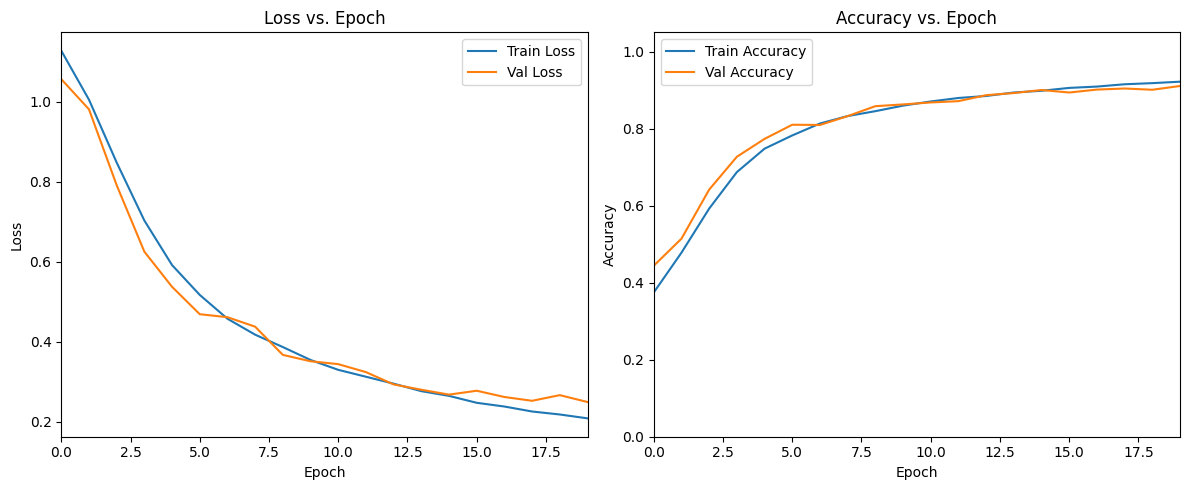


Plotting ROC Curves


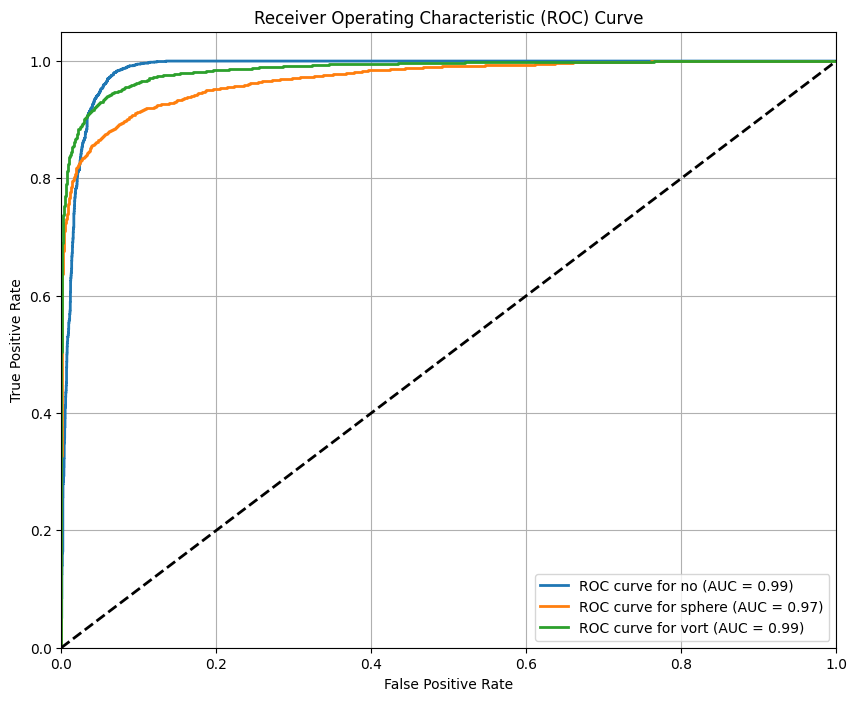


Plotting Confusion Matrix


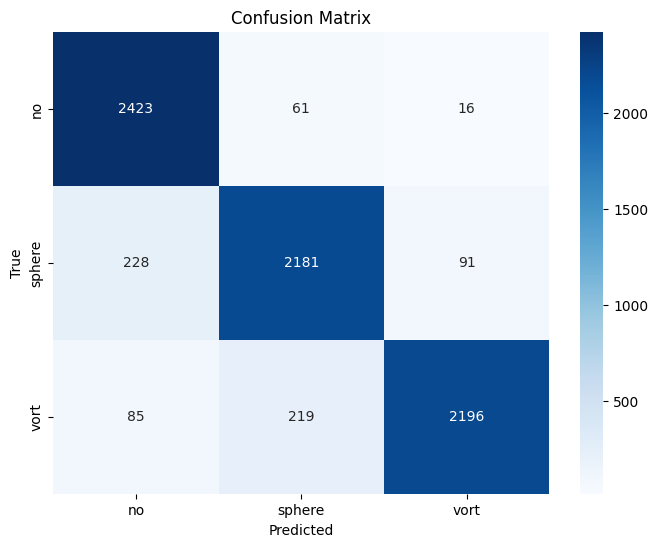

In [21]:
print("Evaluating Baseline Model")
test_loss, test_acc, cm, all_labels, all_preds, all_probs_np, fpr, tpr, roc_auc, macro_roc_auc = evaluate_model(
    model=trained_model,
    test_dataloader=test_dataloader,
    criterion=loss_fn,
    device=device
)

print("\nPlotting Training History")
plot_history(results, save_path='classification_baseline_history.png')

print("\nPlotting ROC Curves")
plot_roc_curves(fpr, tpr, roc_auc, class_names, save_path='classification_baseline_roc.png')

print("\nPlotting Confusion Matrix")
plot_confusion_matrix(cm, class_names, save_path='classfication_baseline_cm.png')